# Bike Lane Quality Classification — Pipeline Prototype (Single-Rider Check)

**Course:** 5ARE0 — Human Activity Recognition Assignment
**Stage:** Data preprocessing → feature engineering → quick supervised-model sanity check

This notebook validates the full pipeline (merge sensors → trim → window → extract features →
train/test split → classify) on **one recording per class** (my own smooth + bumpy rides).

> ⚠️ **Important scope note:** with only one recording per class, this notebook is a
> *pipeline check*, not a real model evaluation. Any accuracy shown here should **not**
> be reported as the model's true performance — see the "Interpretation & caveats" section
> at the end for why, and what changes once group data is added.


## 0. Environment & Reproducibility

Recording the Python version and package versions used, per the assignment's
reproducibility requirement.

In [1]:
import sys
import platform
import pandas as pd
import numpy as np
import sklearn
import matplotlib

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)


Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.9.0
matplotlib: 3.10.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)


## 1. Data Loading & Sensor Merge

Sensor Logger exports `Accelerometer.csv`, `Gravity.csv`, and `Gyroscope.csv` as separate
files. Because all three were recorded at the same sample interval with standardisation
enabled, they share **identical timestamps row-for-row** — confirmed by assertion below,
so a direct column-wise merge is safe (no interpolation/`merge_asof` needed for these three).

`AccelerometerUncalibrated`/`GyroscopeUncalibrated` are not used here: the calibrated
`Accelerometer.csv` already reflects linear acceleration with sensor bias corrected, and
`Gravity.csv` supplies the separated gravity vector.

In [3]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """Merge Accelerometer, Gravity, and Gyroscope CSVs (same clock, same row count)
    into a single per-timestamp dataframe."""
    acc  = pd.read_csv(acc_path).rename(columns={'x': 'acc_x',  'y': 'acc_y',  'z': 'acc_z'})
    grav = pd.read_csv(grav_path).rename(columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'})
    gyro = pd.read_csv(gyro_path).rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    # Sanity check: if this ever fails for a groupmate's phone/export, fall back to
    # pd.merge_asof on 'time' instead of a direct column assignment.
    assert len(acc) == len(grav) == len(gyro), "Row counts differ — use merge_asof instead"
    assert (acc['time'].values == grav['time'].values).all(), "Timestamps misaligned (accel vs gravity)"
    assert (acc['time'].values == gyro['time'].values).all(), "Timestamps misaligned (accel vs gyro)"

    df = acc[['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']].copy()
    df[['grav_x', 'grav_y', 'grav_z']] = grav[['grav_x', 'grav_y', 'grav_z']]
    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[['gyro_x', 'gyro_y', 'gyro_z']]
    return df


In [9]:
from pathlib import Path

print(Path('../data_raw/smooth/Himanshu/Smooth_21/Accelerometer.csv').exists())
print(Path('../data_raw/Bumpy/Himanshu/Bumpy-2026-09-13_14-29-05/Accelerometer.csv').exists())

True
True


In [10]:
# --- EDIT THESE PATHS to point at your own exported recordings ---
# As group data comes in, extend this pattern rather than hardcoding a single pair;
# see the "Next steps" markdown cell for how this generalizes to multiple recordings.

smooth_paths = dict(
    acc_path='../data_raw/smooth/Himanshu/Smooth_21/Accelerometer.csv',
    grav_path='../data_raw/smooth/Himanshu/Smooth_21/Gravity.csv',
    gyro_path='../data_raw/smooth/Himanshu/Smooth_21/Gyroscope.csv',
)
bumpy_paths = dict(
    acc_path='../data_raw/Bumpy/Himanshu/Bumpy-2026-09-13_14-29-05/Accelerometer.csv',
    grav_path='../data_raw/Bumpy/Himanshu/Bumpy-2026-09-13_14-29-05/Gravity.csv',
    gyro_path='../data_raw/Bumpy/Himanshu/Bumpy-2026-09-13_14-29-05/Gyroscope.csv',
)

smooth = load_and_merge(**smooth_paths)
bumpy  = load_and_merge(**bumpy_paths)

print('Smooth raw duration: %.1fs (%d rows)' % (smooth['seconds_elapsed'].max(), len(smooth)))
print('Bumpy raw duration:  %.1fs (%d rows)' % (bumpy['seconds_elapsed'].max(), len(bumpy)))


Smooth raw duration: 85.5s (8540 rows)
Bumpy raw duration:  180.4s (18010 rows)


## 2. Adaptive Trim (Remove Handling Artifacts)

The first/last seconds of a recording often capture the phone being taken out of or put
back into a pocket, not actual riding. Rather than trimming a fixed, guessed time window
(which turned out **not** to be reliably justified when checked visually — see write-up),
this trims adaptively: it finds where the rolling standard deviation of acceleration
magnitude first becomes — and stays — "active" (above `std_threshold` for `min_run`
consecutive samples), and trims everything before/after that point.

**Note:** `std_threshold` was tuned by inspecting the actual rolling-std values at the
start/end of a recording (plotted below) — it is not a universal constant. Re-check this
threshold for each new participant's phone/placement before trusting it blindly.

In [11]:
def adaptive_trim(df, window=100, std_threshold=1.5, min_run=50):
    """Trim leading/trailing stretches where rolling std of accel magnitude hasn't yet
    (or no longer) reached sustained riding-level vibration."""
    mag = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    rolling_std = mag.rolling(window, center=True).std().bfill().ffill()
    active = (rolling_std > std_threshold).astype(int)

    def first_stable_active(seq):
        run = 0
        for i, v in enumerate(seq):
            run = run + 1 if v else 0
            if run >= min_run:
                return i - min_run + 1
        return 0

    start_idx = first_stable_active(active.values)
    end_idx = len(active) - first_stable_active(active.values[::-1])
    return df.iloc[start_idx:end_idx].reset_index(drop=True)


In [12]:
def plot_trim_check(raw_df, trimmed_df, title):
    """Visual sanity check: does the trim remove real handling artifacts, or is it
    cutting into genuine ride data? Always eyeball this before trusting the trim."""
    mag_raw = np.sqrt(raw_df['acc_x']**2 + raw_df['acc_y']**2 + raw_df['acc_z']**2)
    mag_trim = np.sqrt(trimmed_df['acc_x']**2 + trimmed_df['acc_y']**2 + trimmed_df['acc_z']**2)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(raw_df['seconds_elapsed'], mag_raw, alpha=0.4, label='Raw (untrimmed)', color='gray')
    ax.plot(trimmed_df['seconds_elapsed'], mag_trim, alpha=0.9, label='After adaptive trim')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('|a| (m/s²)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


Smooth: 85.5s -> 66.0s
Bumpy:  180.4s -> 163.3s


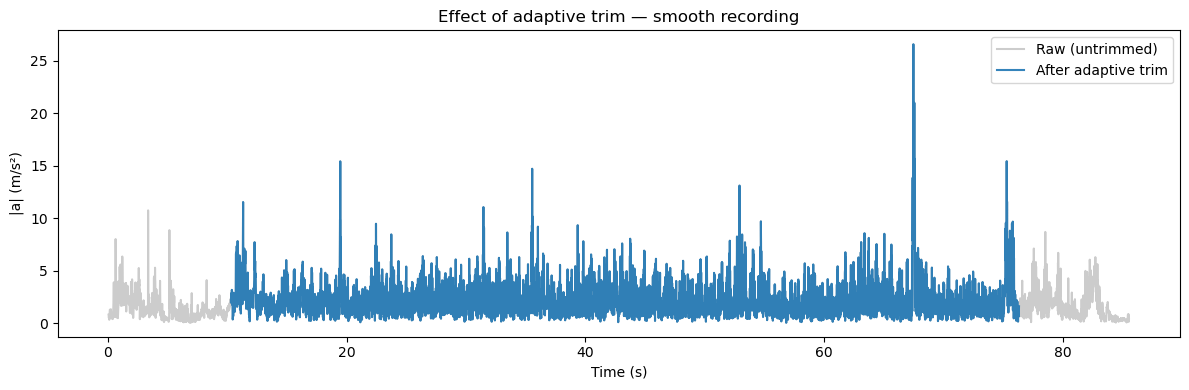

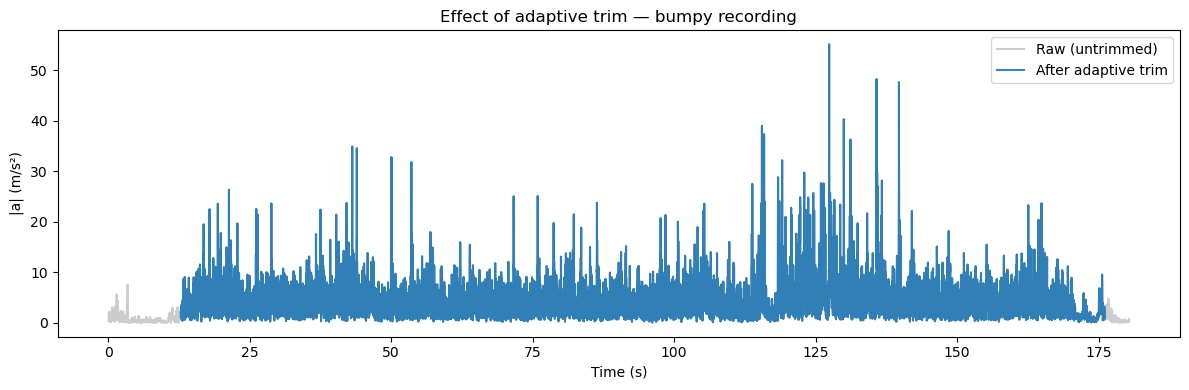

In [13]:
smooth_trimmed = adaptive_trim(smooth)
bumpy_trimmed  = adaptive_trim(bumpy)

print('Smooth: %.1fs -> %.1fs' % (smooth['seconds_elapsed'].max(),
                                   smooth_trimmed['seconds_elapsed'].max() - smooth_trimmed['seconds_elapsed'].min()))
print('Bumpy:  %.1fs -> %.1fs' % (bumpy['seconds_elapsed'].max(),
                                   bumpy_trimmed['seconds_elapsed'].max() - bumpy_trimmed['seconds_elapsed'].min()))

plot_trim_check(smooth, smooth_trimmed, 'Effect of adaptive trim — smooth recording')
plot_trim_check(bumpy, bumpy_trimmed, 'Effect of adaptive trim — bumpy recording')


## 3. Windowing & Feature Extraction

Time-series signals are cut into fixed-length windows (2s, 50% overlap) — a standard
approach for HAR-style sensor classification, since a single instantaneous sample can't
capture "roughness" but a short window of variation can.

For each window, summary statistics are computed per channel (mean, std, min, max, RMS,
IQR) across:
- accelerometer x/y/z + magnitude (captures overall vibration intensity)
- gyroscope x/y/z + magnitude (captures rotational jolts)
- gravity x/y/z (captures phone orientation/tilt — see caveats section on why this
  needs care)

In [14]:
WINDOW = 200   # 2s at ~100Hz
STRIDE = 100   # 1s -> 50% overlap

def make_windows(df, window=WINDOW, stride=STRIDE):
    n = len(df)
    starts = list(range(0, n - window + 1, stride))
    return [df.iloc[s:s+window] for s in starts], starts

def extract_features(win):
    """Summary statistics per channel for one window."""
    feats = {}
    acc_mag  = np.sqrt(win['acc_x']**2  + win['acc_y']**2  + win['acc_z']**2)
    gyro_mag = np.sqrt(win['gyro_x']**2 + win['gyro_y']**2 + win['gyro_z']**2)

    channels = {
        'acc_x': win['acc_x'], 'acc_y': win['acc_y'], 'acc_z': win['acc_z'], 'acc_mag': acc_mag,
        'gyro_x': win['gyro_x'], 'gyro_y': win['gyro_y'], 'gyro_z': win['gyro_z'], 'gyro_mag': gyro_mag,
        'grav_x': win['grav_x'], 'grav_y': win['grav_y'], 'grav_z': win['grav_z'],
    }
    for name, series in channels.items():
        feats[f'{name}_mean'] = series.mean()
        feats[f'{name}_std']  = series.std()
        feats[f'{name}_min']  = series.min()
        feats[f'{name}_max']  = series.max()
        feats[f'{name}_rms']  = np.sqrt(np.mean(series**2))
        feats[f'{name}_iqr']  = series.quantile(0.75) - series.quantile(0.25)
    return feats

def build_dataset(df, label, recording_id):
    """Window one recording and extract features + label + recording ID for every window."""
    windows, starts = make_windows(df)
    rows = []
    for win, s in zip(windows, starts):
        f = extract_features(win)
        f['label'] = label            # 0 = smooth, 1 = bumpy
        f['recording'] = recording_id # tracks provenance -> used for leakage-free splitting
        f['window_start_t'] = win['seconds_elapsed'].iloc[0]
        rows.append(f)
    return pd.DataFrame(rows)


In [15]:
smooth_feats = build_dataset(smooth_trimmed, label=0, recording_id='smooth_me')
bumpy_feats  = build_dataset(bumpy_trimmed,  label=1, recording_id='bumpy_me')

print('Smooth windows:', len(smooth_feats))
print('Bumpy windows:', len(bumpy_feats))

data = pd.concat([smooth_feats, bumpy_feats], ignore_index=True)
data.head()


Smooth windows: 64
Bumpy windows: 162


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_rms,acc_x_iqr,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_y_rms,acc_y_iqr,acc_z_mean,acc_z_std,acc_z_min,acc_z_max,acc_z_rms,acc_z_iqr,acc_mag_mean,acc_mag_std,acc_mag_min,acc_mag_max,acc_mag_rms,acc_mag_iqr,gyro_x_mean,gyro_x_std,gyro_x_min,gyro_x_max,gyro_x_rms,gyro_x_iqr,gyro_y_mean,gyro_y_std,gyro_y_min,gyro_y_max,gyro_y_rms,gyro_y_iqr,gyro_z_mean,gyro_z_std,gyro_z_min,gyro_z_max,gyro_z_rms,gyro_z_iqr,gyro_mag_mean,gyro_mag_std,gyro_mag_min,gyro_mag_max,gyro_mag_rms,gyro_mag_iqr,grav_x_mean,grav_x_std,grav_x_min,grav_x_max,grav_x_rms,grav_x_iqr,grav_y_mean,grav_y_std,grav_y_min,grav_y_max,grav_y_rms,grav_y_iqr,grav_z_mean,grav_z_std,grav_z_min,grav_z_max,grav_z_rms,grav_z_iqr,label,recording,window_start_t
0,0.076195,3.190112,-7.400362,7.320750,3.183039,3.867193,-0.006800,1.207437,-3.420294,7.496986,1.204434,1.424305,-0.144848,1.641686,-6.082681,9.302385,1.643971,1.840752,3.266731,1.905693,0.195601,11.557179,3.779555,2.494813,0.002410,0.077744,-0.619068,0.394492,0.077587,0.068031,-0.140750,0.506742,-1.035155,0.991982,0.524704,0.586513,-0.091301,0.317918,-0.828582,0.636803,0.330004,0.379138,0.536257,0.321218,0.061569,1.308524,0.624689,0.453698,0.535833,0.383746,-0.004616,1.379244,0.658515,0.703133,9.606006,0.027751,9.502859,9.631562,9.606046,0.036253,1.859981,0.033270,1.814673,1.990919,1.860277,0.035779,0,smooth_me,10.304363
1,0.295412,2.568418,-7.294992,6.633024,2.578964,3.258569,-0.003930,1.130143,-3.420294,7.496986,1.127321,1.214228,-0.220828,1.412127,-6.082681,9.302385,1.425797,1.427075,2.678333,1.671919,0.195601,11.557179,3.155123,1.702506,0.016678,0.079416,-0.619068,0.177151,0.080953,0.101417,0.002629,0.602582,-0.899054,1.169417,0.601079,1.065830,-0.034296,0.410070,-0.669057,0.867963,0.410479,0.528674,0.643616,0.350306,0.061569,1.438124,0.732354,0.525303,0.796284,0.631723,-0.004616,1.872414,1.015454,1.174186,9.569687,0.072885,9.411150,9.631562,9.569963,0.099181,1.884496,0.061079,1.810494,2.027303,1.885481,0.060314,0,smooth_me,11.305551
2,0.159606,1.605610,-5.660830,3.718980,1.609524,1.629698,-0.016738,0.906778,-2.186789,2.700080,0.904663,1.206691,-0.108898,0.849765,-2.424610,1.908681,0.854604,1.238191,1.751697,1.037434,0.162800,5.930305,2.034535,1.222330,0.023979,0.054241,-0.081847,0.177151,0.059181,0.071950,0.098501,0.508357,-0.715806,1.169417,0.516563,0.775892,0.029428,0.363455,-0.592100,0.867963,0.363737,0.338740,0.491559,0.402273,0.018498,1.438124,0.634543,0.658807,0.728767,0.636207,0.071302,1.872414,0.966352,1.125627,9.577459,0.076988,9.411150,9.633413,9.577767,0.105308,1.870440,0.066318,1.810234,2.027303,1.871609,0.067093,0,smooth_me,12.306739
3,0.049711,1.476433,-5.393107,3.454931,1.473576,1.626256,0.052786,1.133358,-3.385584,3.327998,1.131752,1.481126,-0.206900,1.125848,-3.002135,2.872034,1.141930,1.498906,1.898371,1.076230,0.162800,6.024179,2.180893,1.461215,-0.000252,0.040900,-0.125650,0.121320,0.040798,0.048732,-0.051087,0.309793,-0.664250,0.662608,0.313212,0.412777,0.010508,0.191904,-0.323476,0.482196,0.191712,0.195491,0.296577,0.220922,0.018498,0.796913,0.369486,0.346030,0.263753,0.184316,-0.064514,0.749824,0.321509,0.214846,9.628769,0.006712,9.604570,9.635468,9.628772,0.003128,1.831225,0.019794,1.793935,1.879229,1.831332,0.026087,0,smooth_me,13.307925
4,0.195193,1.866538,-5.393107,3.454931,1.872069,2.225253,-0.029683,1.294389,-4.065017,3.327998,1.291490,1.729441,-0.092332,1.267060,-3.020980,3.258499,1.267257,1.813843,2.350159,1.123206,0.372791,6.024179,2.603561,1.449990,0.000222,0.047119,-0.125650,0.121320,0.047002,0.063260,-0.122207,0.379795,-0.664250,0.662608,0.398067,0.533908,-0.022266,0.248337,-0.363557,0.611189,0.248714,0.299865,0.417908,0.219361,0.030642,0.864393,0.471726,0.368226,0.238017,0.293721,-0.228811,0.749824,0.377482,0.444054,9.626410,0.008626,9.604570,9.639379,9.626413,0.010730,1.832765,0.032174,1.785485,1.905043,1.833046,0.050576,0,smooth_me,14.309114


## 4. Train/Test Split — Leakage-Aware

**Why not a random split?** Adjacent/overlapping windows from the same continuous ride
are highly correlated (same road, same speed, same few seconds repeated with 50% overlap).
A random shuffle would let near-duplicate windows appear in both train and test, inflating
accuracy without meaning anything.

Instead: for each recording, the **last `1 - split_frac` of its duration** is held out as
test, with a small gap around the cut so no window straddles the boundary or overlaps a
training window.

**This is still not a "real" evaluation** — it only checks that the pipeline can generalize
across *time* within the same two rides, not across *different people, phones, or routes*.
See the caveats section.

In [16]:
def time_split(df, split_frac=0.75, gap_seconds=WINDOW/100):
    """Per-recording, time-ordered split with a gap to avoid overlap leakage across
    the train/test boundary."""
    train_parts, test_parts = [], []
    for rec, g in df.groupby('recording'):
        t_min, t_max = g['window_start_t'].min(), g['window_start_t'].max()
        split_t = t_min + split_frac * (t_max - t_min)
        train_parts.append(g[g['window_start_t'] <= split_t - gap_seconds / 2])
        test_parts.append(g[g['window_start_t'] >= split_t + gap_seconds / 2])
    return pd.concat(train_parts), pd.concat(test_parts)

train_df, test_df = time_split(data)
print('Train windows:', len(train_df), '| Test windows:', len(test_df))
print('\nTrain label counts:\n', train_df['label'].value_counts())
print('\nTest label counts:\n', test_df['label'].value_counts())


Train windows: 167 | Test windows: 55

Train label counts:
 label
1    120
0     47
Name: count, dtype: int64

Test label counts:
 label
1    40
0    15
Name: count, dtype: int64


In [17]:
feature_cols = [c for c in data.columns if c not in ('label', 'recording', 'window_start_t')]

X_train, y_train = train_df[feature_cols], train_df['label']
X_test,  y_test  = test_df[feature_cols],  test_df['label']

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


## 5. Quick Supervised Models (Sanity Check)

Two simple baselines to confirm the features are separable at all. This is **not** the
final 4-model supervised comparison the assignment requires — just a fast check that the
pipeline produces a learnable signal before scaling up to the full group dataset.

In [18]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    results[name] = (model, preds, acc)

    print(f'=== {name} ===')
    print('Test accuracy:', round(acc, 3))
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=['smooth', 'bumpy']))
    print()


=== LogisticRegression ===
Test accuracy: 0.909
[[15  0]
 [ 5 35]]
              precision    recall  f1-score   support

      smooth       0.75      1.00      0.86        15
       bumpy       1.00      0.88      0.93        40

    accuracy                           0.91        55
   macro avg       0.88      0.94      0.90        55
weighted avg       0.93      0.91      0.91        55


=== RandomForest ===
Test accuracy: 0.909
[[15  0]
 [ 5 35]]
              precision    recall  f1-score   support

      smooth       0.75      1.00      0.86        15
       bumpy       1.00      0.88      0.93        40

    accuracy                           0.91        55
   macro avg       0.88      0.94      0.90        55
weighted avg       0.93      0.91      0.91        55




Top 10 features (Random Forest):
gyro_x_iqr     0.089365
grav_y_max     0.085383
gyro_x_rms     0.075758
gyro_x_std     0.071258
grav_y_mean    0.070543
grav_z_rms     0.065835
grav_z_max     0.060000
grav_y_min     0.055145
acc_y_iqr      0.053649
grav_y_rms     0.052649
dtype: float64


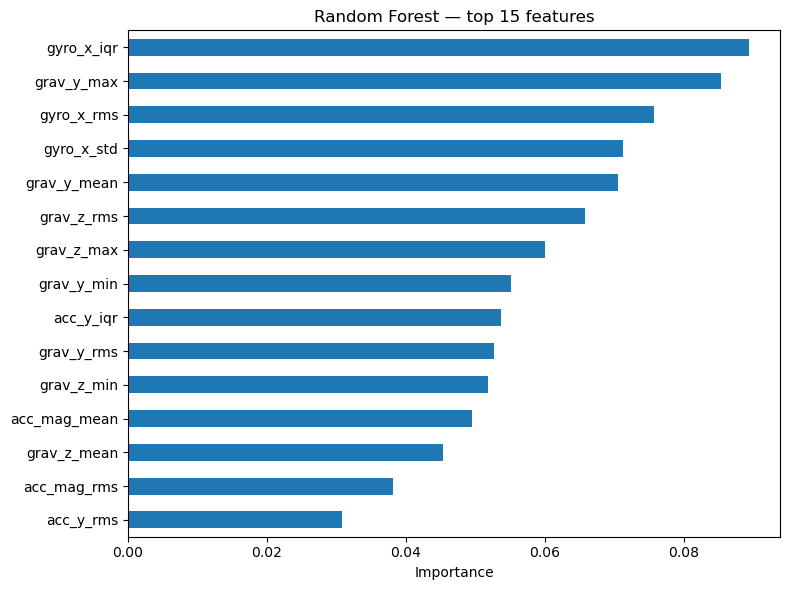

In [19]:
# Feature importance (Random Forest) — which channels is the model actually using?
rf_model = results['RandomForest'][0]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('Top 10 features (Random Forest):')
print(importances.head(10))

importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest — top 15 features')
plt.tight_layout()
plt.show()


## 6. Interpretation & Caveats — Read Before Trusting These Numbers

**The pipeline works** — it runs end-to-end and produces a learnable, separable signal
between smooth and bumpy windows. That was the goal of this notebook.

**The accuracy number is not yet meaningful as a model-performance claim**, for one
specific reason worth stating plainly: with **one recording per class**, the model cannot
distinguish "learned actual road roughness" from "learned to tell these two specific rides
apart." Any difference between the two rides — route, phone tilt, weather, time of day —
is fully confounded with the smooth/bumpy label.

This shows up concretely in the feature importances: gravity-derived features
(`grav_y`, `grav_z`) rank highly, and gravity reflects **phone orientation/tilt**, not
surface texture. If the two rides differed in handlebar angle or route geometry
independent of the actual lane surface, the model may be partly keying off that rather
than "bumpiness" itself.

**Next steps once group data is added:**
1. Extend `smooth_paths` / `bumpy_paths` above into a list covering every participant's
   recordings (see commented pattern in Section 1).
2. Replace the per-recording time-split with **leave-one-recording-out cross-validation**:
   train on every recording except one, test on the held-out one, repeat for each
   recording. If accuracy holds up when testing on a person/route the model has never
   seen, that's real evidence of generalization — not just memorizing one ride's quirks.
3. Re-run the adaptive-trim threshold check (Section 2) for each new participant's data
   before assuming `std_threshold=1.5` transfers — it was tuned on one phone/placement
   and may not hold for another.
